In [1]:
from nns.memorygraphs.memorypool import FoveatedGraphMemory
mem = FoveatedGraphMemory(H=512, W=512)

from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

In [2]:
from trail.pic_tools import *
from trail.matrix_tools import *

In [3]:
image_path = 'picture/OIP-C.jpg'  # [1, 3, 1280, 1920]
tensor, oringinal_image = image_to_tensor(image_path)

center_x = -1
center_y = -1
current_fix = (100, 100)

In [26]:
retina_out = retina(tensor, center_x = center_x, center_y = center_y)
cropped = retina_out[5]
msfb_out = msbank(cropped)

res = mem.run_one_step(retina_out, msfb_out, current_fix)
if res['move'] is not None:
    _, _, target = res['move']
    center_x = target[0]
    center_y = target[1]
    current_fix = (float(target[0]), float(target[1]))
    print(current_fix)
print(res['matched'], res['learned_nodes'])

(80.0, 92.0)
True [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9, 10, 11, 8, 9, 10, 11, 8, 9, 10, 11, 8, 9, 10, 11, 12, 13, 14, 15, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9, 10, 11, 8, 9, 10, 11, 8, 9, 10, 11, 8, 9, 10, 11, 12, 13, 14, 15, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 4, 5, 6, 7, 8, 9, 10, 11, 8, 9, 10, 11, 8, 9, 10, 11, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 17, 18, 19, 20, 17, 18, 19, 20, 17, 18, 19, 20, 21, 22, 23, 24, 21, 22, 23, 24, 21, 22, 23, 24, 21, 22, 23, 24, 25, 26, 27, 28, 25, 26, 27, 28, 25, 26, 27, 28, 25, 26, 27, 28, 97, 30, 31, 32, 17, 18, 19, 20, 17, 18, 19, 20, 17, 18, 19, 20, 17, 18, 19, 20, 21, 22, 23, 24, 21, 22, 23, 24, 21, 22, 23, 24, 21, 22, 23, 24, 25, 26, 27, 28, 25, 26, 27, 28, 25, 26, 27, 28, 25, 26, 27, 28, 97, 30, 31, 32, 17, 18, 19, 20, 17, 18, 19, 20, 17, 18, 19, 20, 17, 18, 19, 2

In [32]:
center_x = 300
center_y = 200
current_fix = (center_x, center_y)

retina_out = retina(tensor, center_x = center_x, center_y = center_y)
cropped = retina_out[5]
msfb_out = msbank(cropped)

res = mem.run_one_step(retina_out, msfb_out, current_fix)
if res['move'] is not None:
    _, _, target = res['move']
    center_x = target[0]
    center_y = target[1]
    current_fix = (float(target[0]), float(target[1]))
    print(current_fix)
print(res['matched'], res['learned_nodes'])

(298.25866050808315, 206.01847575057738)
True [383, 384, 385, 386, 387, 384, 385, 386, 387, 384, 385, 386, 387, 384, 385, 386, 387, 388, 389, 390, 391, 392, 388, 389, 390, 391, 388, 389, 390, 391, 393, 388, 389, 390, 391, 394, 395, 396, 397, 398, 399, 395, 396, 397, 398, 394, 395, 396, 397, 398, 395, 396, 397, 398, 400, 401, 402, 403, 404, 384, 385, 386, 387, 405, 384, 385, 386, 387, 404, 384, 385, 386, 387, 405, 384, 385, 386, 387, 406, 388, 389, 390, 391, 392, 388, 389, 390, 391, 394, 388, 389, 390, 391, 407, 388, 389, 390, 391, 408, 395, 396, 397, 398, 409, 395, 396, 397, 398, 395, 396, 397, 398, 395, 396, 397, 398, 400, 401, 402, 403, 404, 384, 385, 386, 387, 404, 384, 385, 386, 387, 404, 384, 385, 386, 387, 404, 384, 385, 386, 387, 393, 388, 389, 390, 391, 393, 388, 389, 390, 391, 393, 388, 389, 390, 391, 393, 388, 389, 390, 391, 393, 395, 396, 397, 398, 410, 396, 397, 398, 395, 396, 397, 398, 395, 396, 397, 398, 400, 401, 402, 403, 411, 412, 413, 414, 415, 416, 412, 413, 414, 415

In [24]:
from trail.foveated_visualization2 import visualize_step

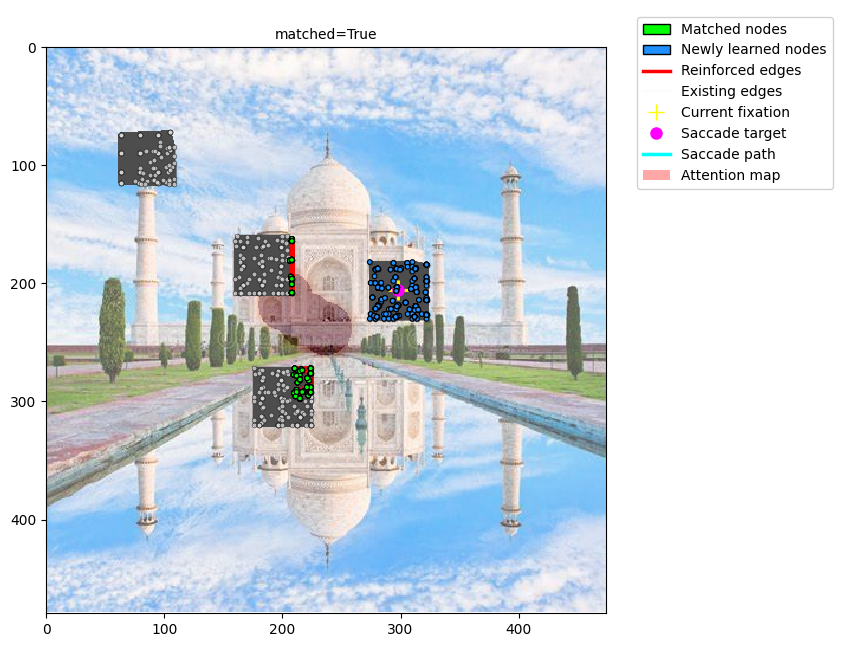

In [33]:

visualize_step(oringinal_image, mem, res, current_fix= current_fix)